# Basic Visualizations and Descriptive Statistics of Spike Train Data


## Load the spike train data


In [1]:
load('Ch8-spikes-1.mat')


## Step 1


In [2]:
size(SpikesLow)

T = 30; %The duration of the recording in seconds,
n = size(SpikesLow, 2); %...and # spikes in low light condition,
f = n / T; %... to compute the firing rate.


ans = 1x2 double
     1   750

### Figure 8.1


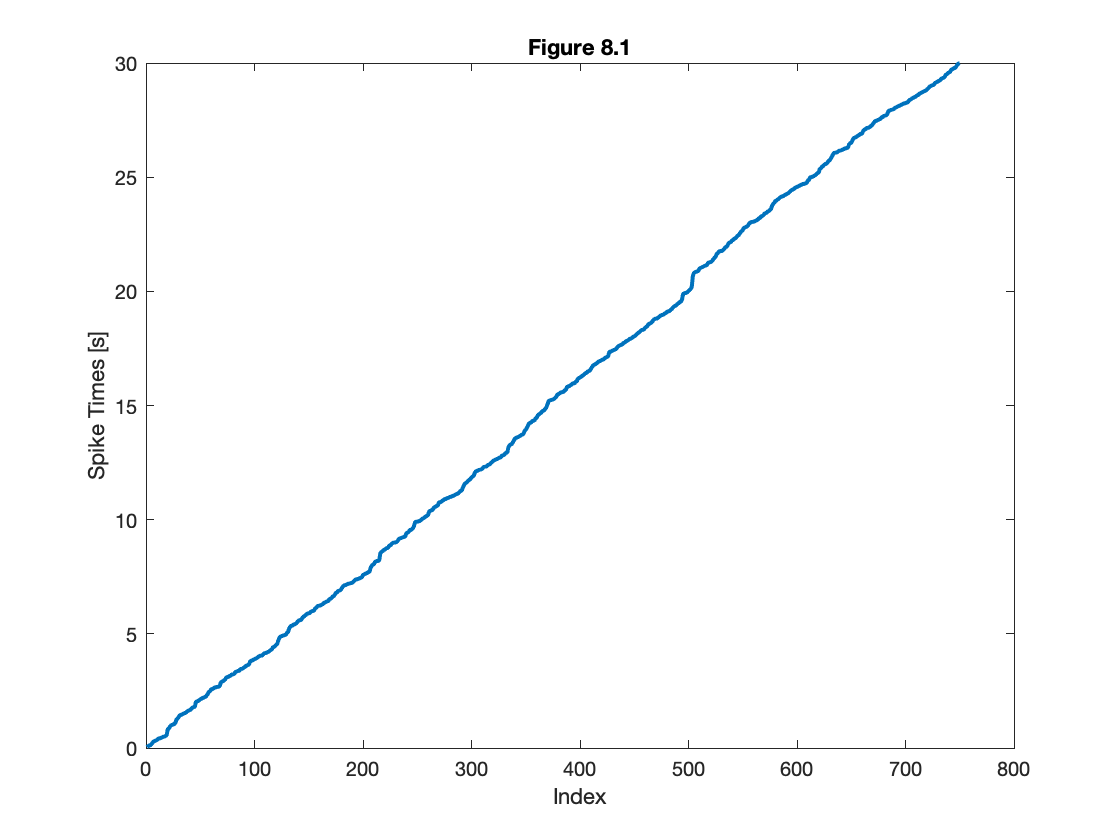

In [3]:
figure
plot(SpikesLow, 'LineWidth', 2)
xlabel('Index')
ylabel('Spike Times [s]')
title('Figure 8.1')


### Figure 8.2


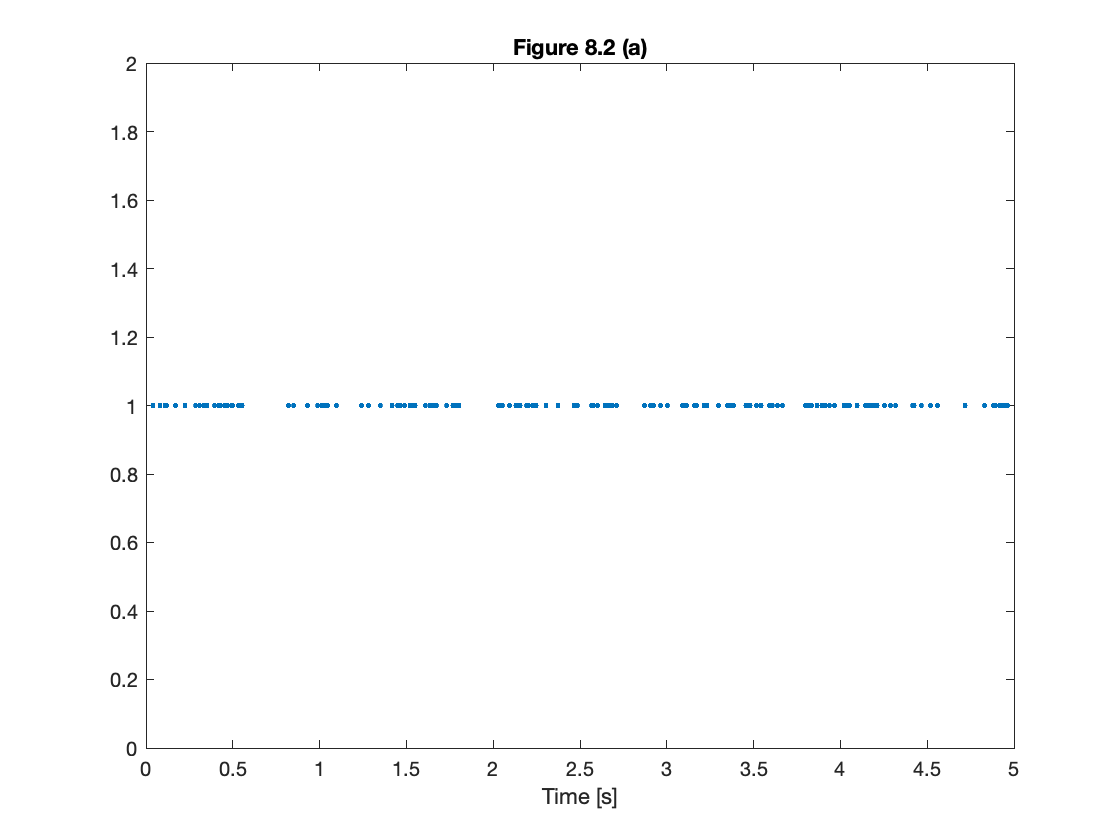

In [4]:
figure
plot(SpikesLow, ones(size(SpikesLow)), '.'); %Plot spikes as a row,
xlim([0 5]); %...display times (0,5)s,
xlabel('Time [s]') %...label the x-axis.
title('Figure 8.2 (a)')


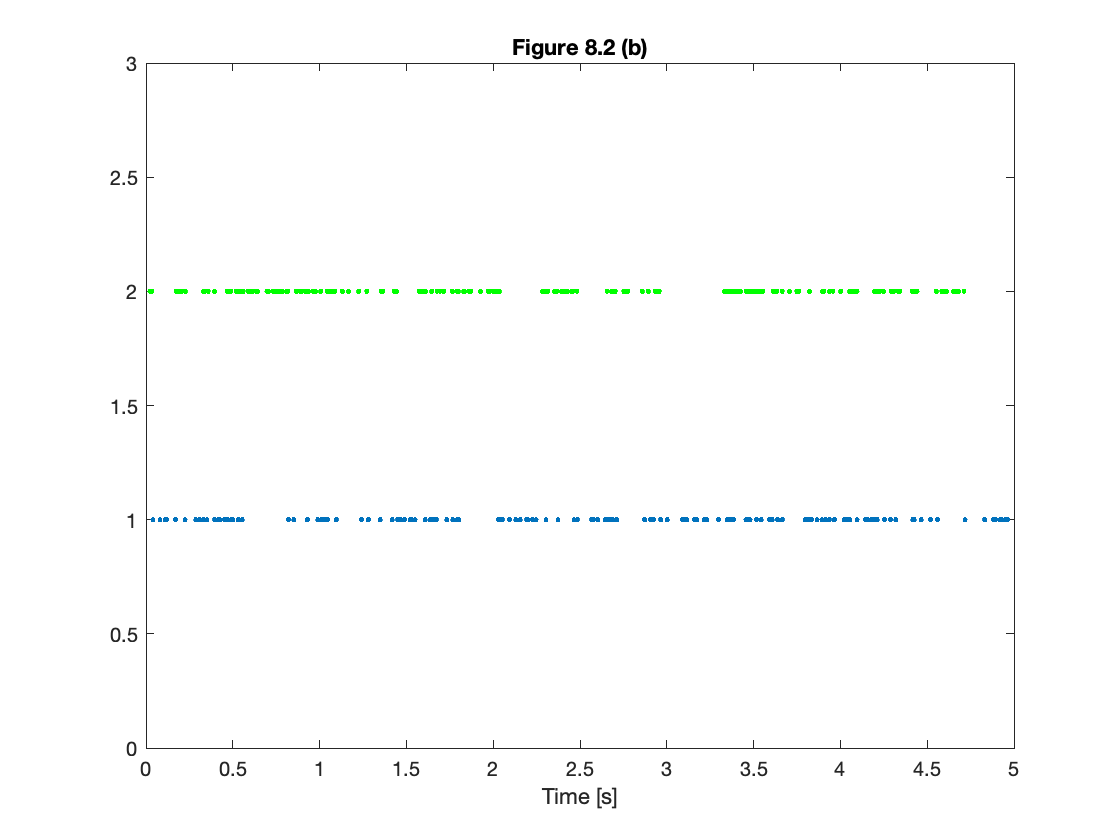

In [5]:
figure
% Plot low light condition spikes:
plot(SpikesLow, ones(size(SpikesLow)), '.');
hold on %... freeze the graphics window.
% Plot high light condition spikes:
plot(SpikesHigh, 2 * ones(size(SpikesHigh)), '.g');
hold off %... release the graphics window,
xlim([0 5]); %... and display times 0 to 5 s,
ylim([0 3]); %... set y-axis range,
xlabel('Time [s]') %... and label the x-axis.
title('Figure 8.2 (b)')


### Figure 8.3


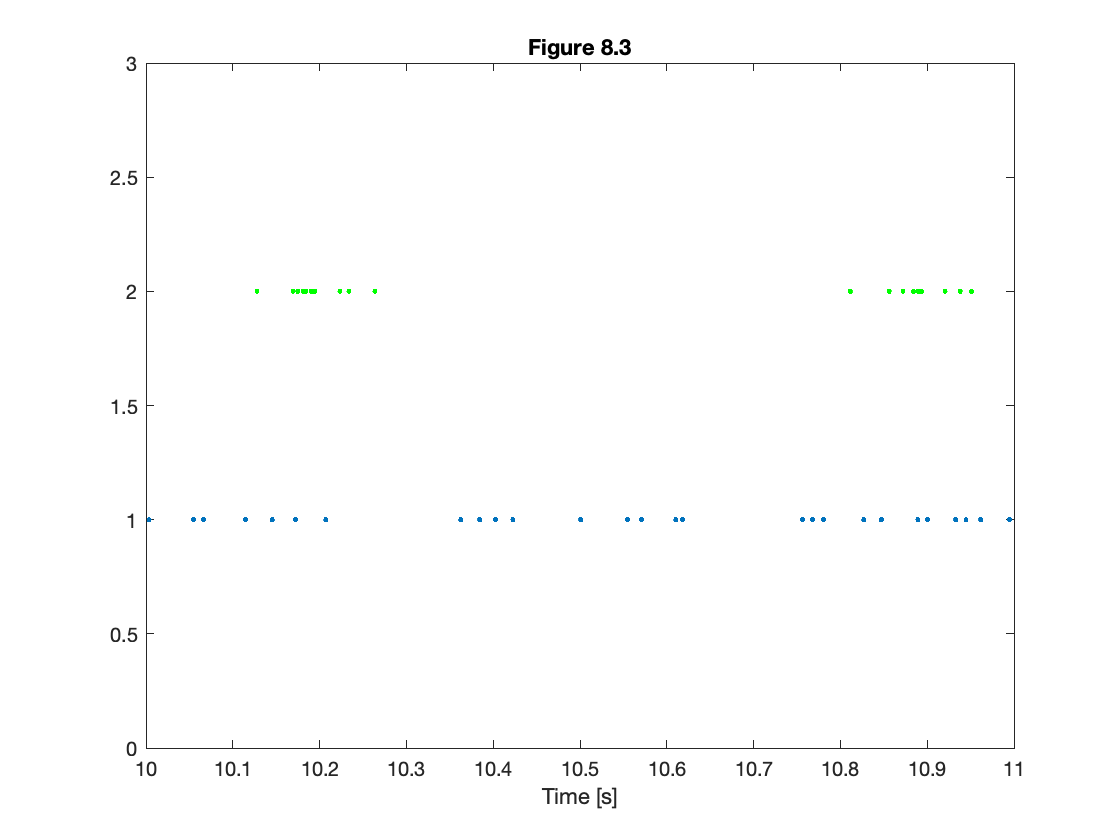

In [6]:
figure
% Plot low light condition spikes:
plot(SpikesLow, ones(size(SpikesLow)), '.');
hold on %... freeze the graphics window.
% Plot high light condition spikes:
plot(SpikesHigh, 2 * ones(size(SpikesHigh)), '.g');
hold off %... release the graphics window,
xlim([10 11]); %... and display times 0 to 5 s,
ylim([0 3]); %... set y-axis range,
xlabel('Time [s]') %... and label the x-axis.
title('Figure 8.3')


## Step 2


In [7]:
ISIsLow = diff(SpikesLow); %Compute ISIs in low light condition.
ISIsHigh = diff(SpikesHigh); %Compute ISIs in high light condition.


### Figure 8.4


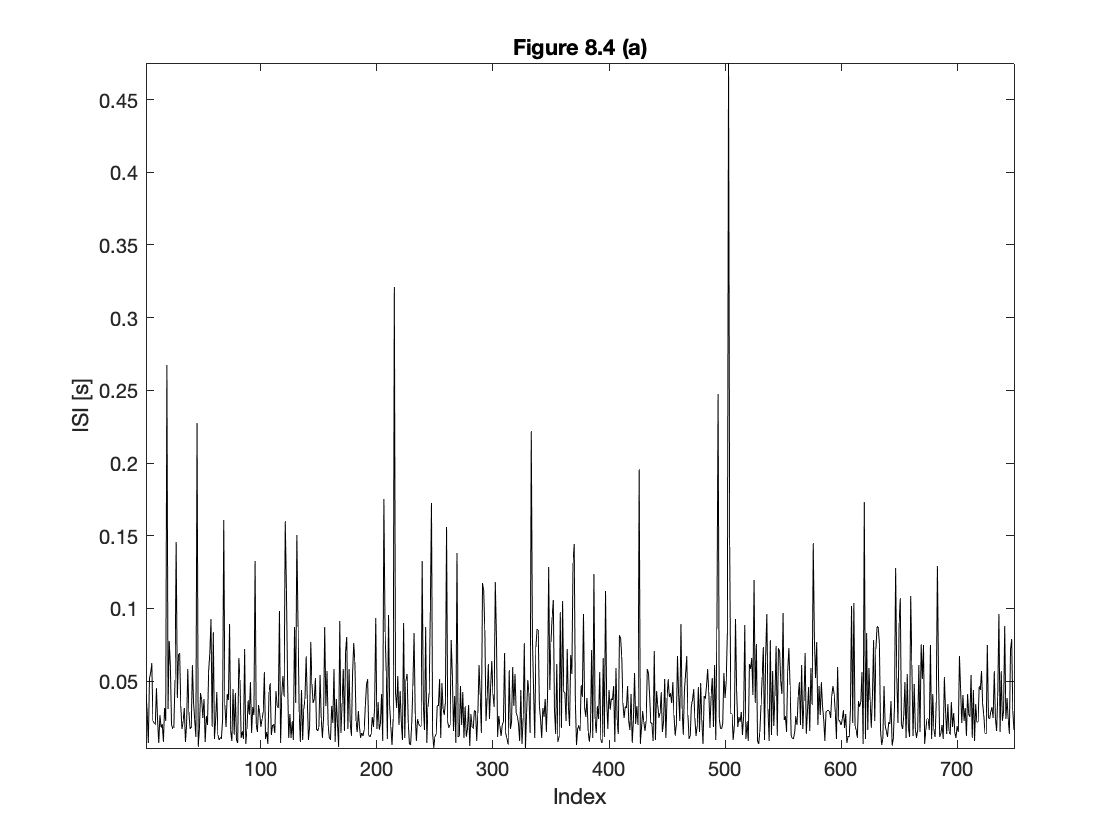

In [8]:
figure
plot(ISIsLow, 'k')
axis tight
xlabel('Index')
ylabel('ISI [s]')
title('Figure 8.4 (a)')


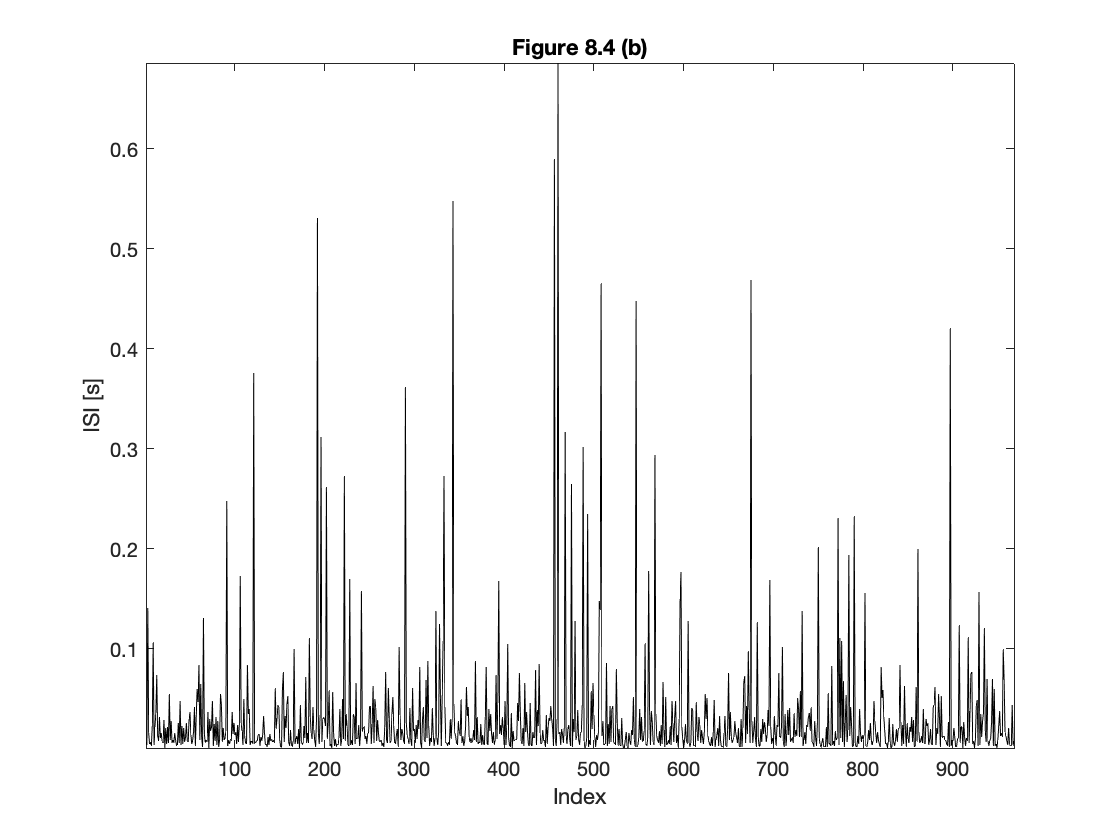

In [9]:
figure
plot(ISIsHigh, 'k')
axis tight
xlabel('Index')
ylabel('ISI [s]')
title('Figure 8.4 (b)')


### Figure 8.5


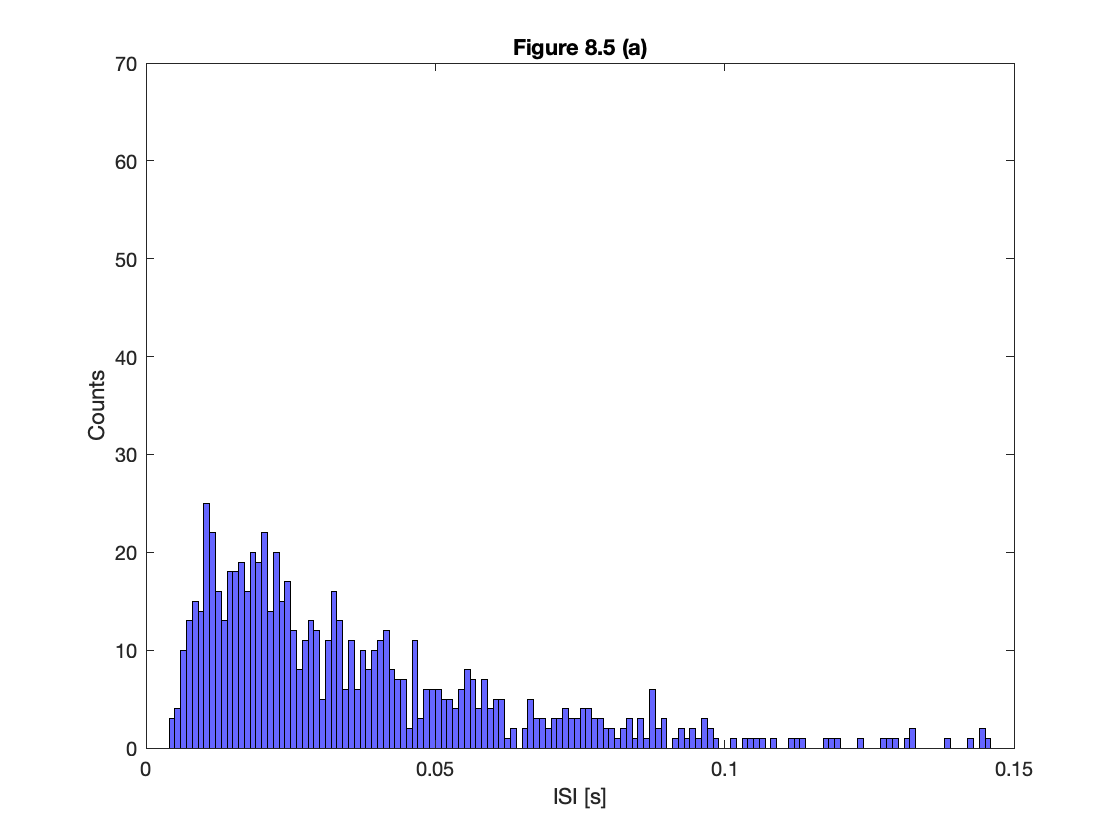

In [10]:
bins = (0:0.001:0.5); %Define the bins for the histogram.

figure
histogram(ISIsLow, bins, 'FaceColor', 'b') %Plot the histogram of the ISI data,
xlim([0 0.15]) %... focus on ISIs from 0 to 150 ms,
ylim([0 70])
xlabel('ISI [s]') %... label the x-axis,
ylabel('Counts') %... and the y-axis.
title('Figure 8.5 (a)')


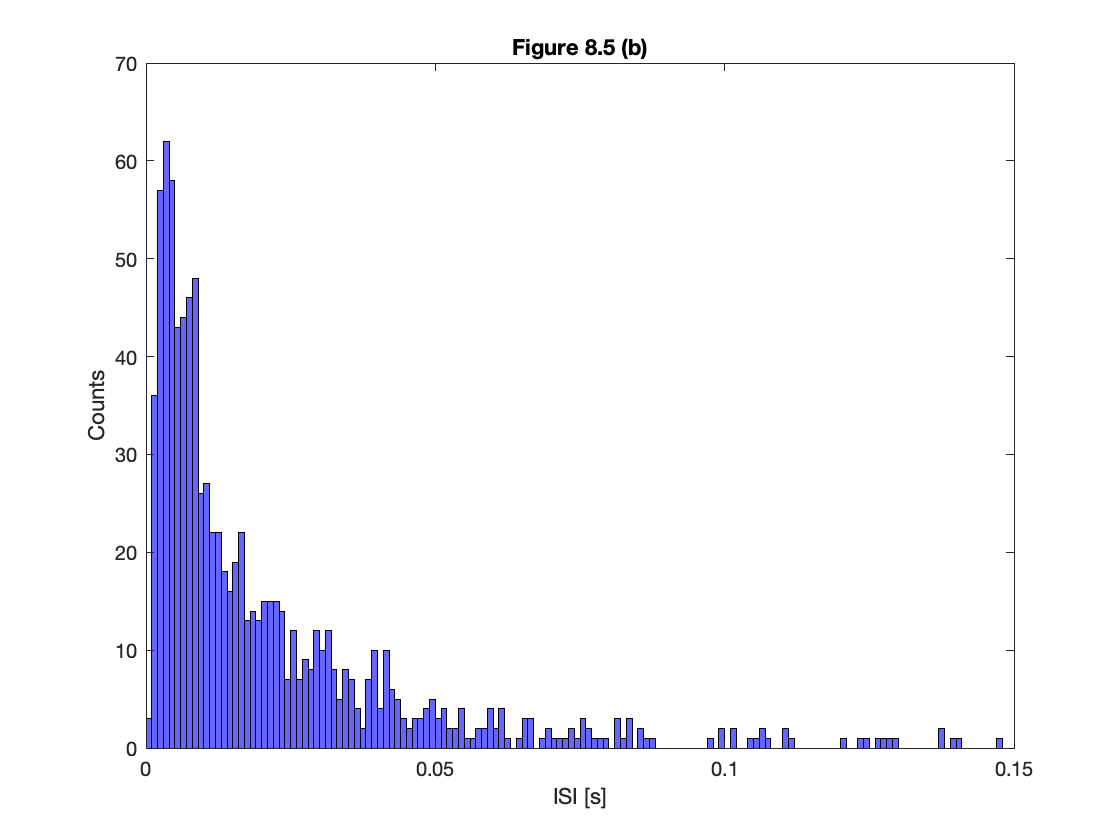

In [11]:
bins = (0:0.001:0.5); %Define the bins for the histogram.

figure
histogram(ISIsHigh, bins, 'FaceColor', 'b') %Plot the histogram of the ISI data,
xlim([0 0.15]) %... focus on ISIs from 0 to 150 ms,
ylim([0 70])
xlabel('ISI [s]') %... label the x-axis,
ylabel('Counts') %... and the y-axis.
title('Figure 8.5 (b)')


## Step 3


### Figure 8.7

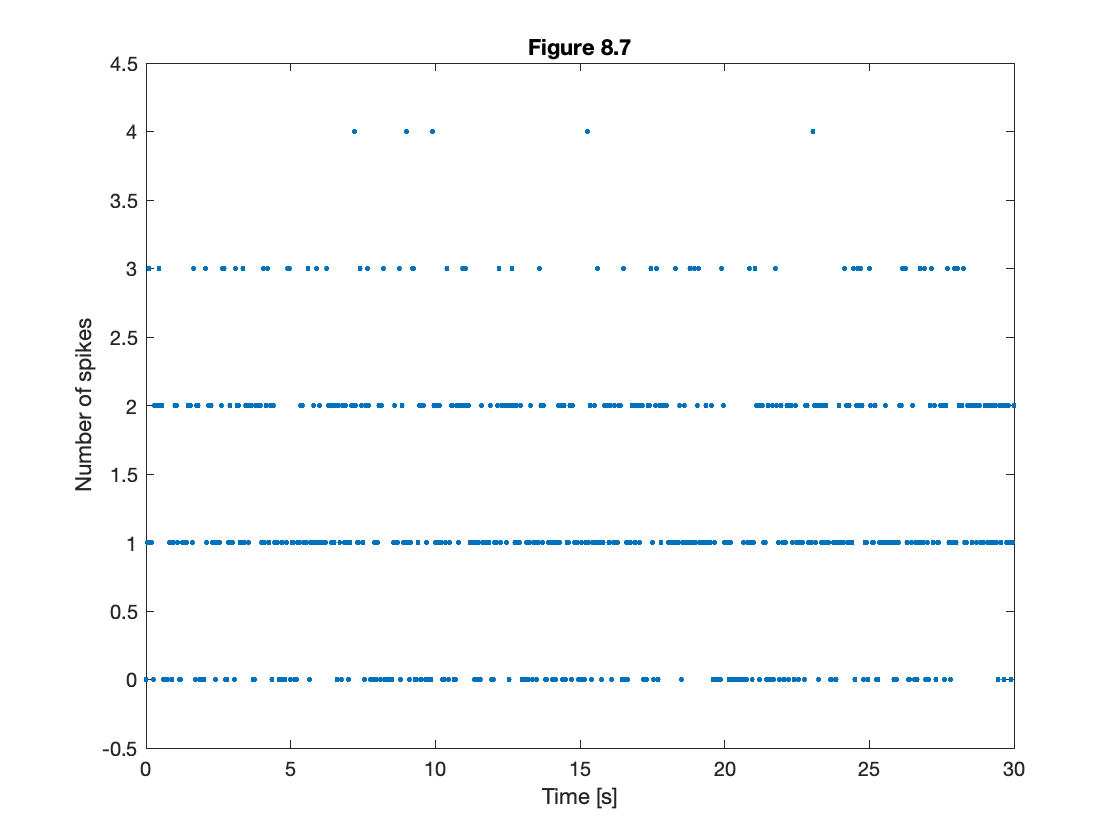

In [12]:
time_bins = (0:0.05:30); %Define time bins, 50ms increments,
%... compute a histogram of spike time data,
IncrementsLow50 = hist(SpikesLow, time_bins);
%... and plot the resulting counts versus time,

figure
plot(time_bins, IncrementsLow50, '.')
ylim([- .5, 4.5])
ylabel('Number of spikes') % with x-axis labelled,
xlabel('Time [s]') % and y-axis labelled.
title('Figure 8.7')


### Figure 8.8 Fano Factor

Fano factor (50 ms bins, low light): 0.7186
Number of bins: 601


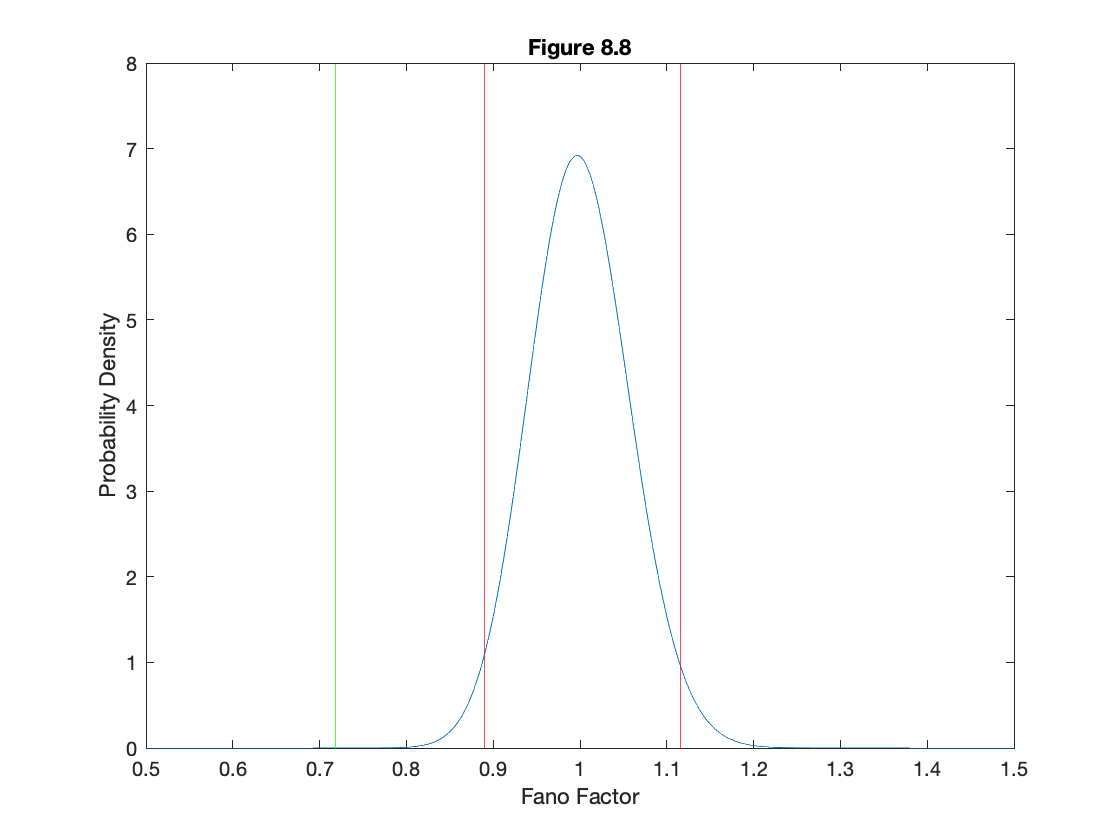

In [13]:
FF50Low = var(IncrementsLow50) / mean(IncrementsLow50);
N = length(IncrementsLow50); % determine number of time bins.
fprintf('Fano factor (50 ms bins, low light): %6.4f\n', FF50Low)
fprintf('Number of bins: %d\n', N)

% 95% confidence interval for the Fano factor
ci = [0.025, 0.975]; % define the confidence interval.
ff = gaminv(ci, (N - 1) / 2, 2 / (N - 1));

FF = (0.5:0.001:1.5); %Define possible FF values for plot,
Y = gampdf(FF, (N - 1) / 2, 2 / (N - 1)); %... compute gamma distribution,

% plot
figure
plot(FF, Y); %... and plot it.
hold on
xline(FF50Low, 'g')
xline(ff, 'r') % plot the confidence interval,
ylim([0, 8]) %... set y-axis range,
xlabel('Fano Factor') %... label the x-axis,
ylabel('Probability Density') %... and the y-axis.

title('Figure 8.8')


## Step 4

### Figure 8.11

ans = 1x7 double
    0.0132    0.0166    0.1022    1.0000    0.1022    0.0166    0.0132

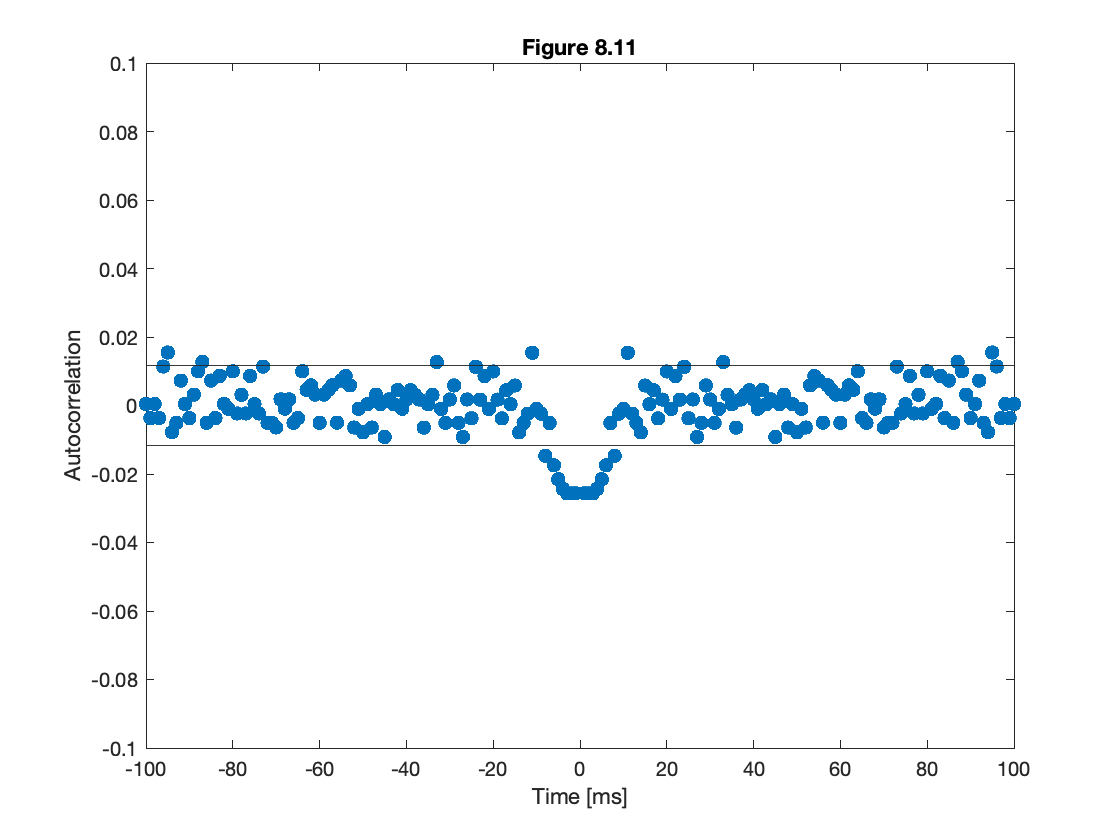

In [14]:
% Compute autocorrelation of increments process for low light.
xcorr(IncrementsLow50 - mean(IncrementsLow50), 3, 'coeff')

% Define time bins, 1 ms increments,
time_bins = (0:0.001:30);
% ... compute histogram to create increments process,
IncrementsLow1 = hist(SpikesLow, time_bins);
%... and then compute the autocorrelation function.
ACFLow = xcorr(IncrementsLow1 - mean(IncrementsLow1), 100, 'coeff');
N1 = length(IncrementsLow1); %... compute the sample size,

figure
plot(-100:100, ACFLow, '.', 'MarkerSize', 20) %Plot autocorrelation vs lags,
%... and plot the upper and lower significance lines,
yline([2 / sqrt(N1) 2 / sqrt(N1)])
yline(- [2 / sqrt(N1) 2 / sqrt(N1)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.11')


### Figure 8.12

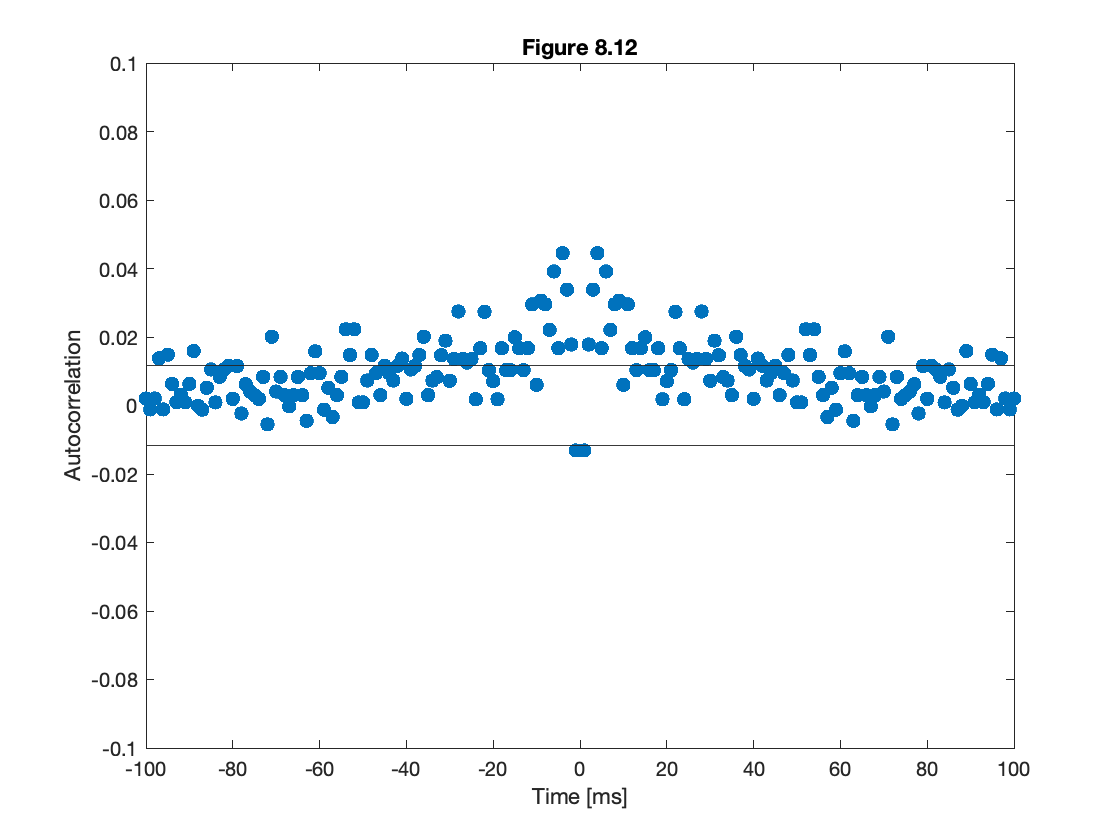

In [15]:
% Define time bins (1 ms increments), compute increments & ACF.
time_bins = (0:0.001:30);
IncrementsHigh1 = hist(SpikesHigh, time_bins);
ACFHigh = xcorr(IncrementsHigh1 - mean(IncrementsHigh1), 100, 'coeff');
N2 = length(IncrementsHigh1);

% Plot the autocorrelation vs lags with significance lines.
figure
plot(-100:100, ACFHigh, '.', 'MarkerSize', 20)
yline([2 / sqrt(N2) 2 / sqrt(N2)])
yline(- [2 / sqrt(N2) 2 / sqrt(N2)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.12')


### Figure 8.13

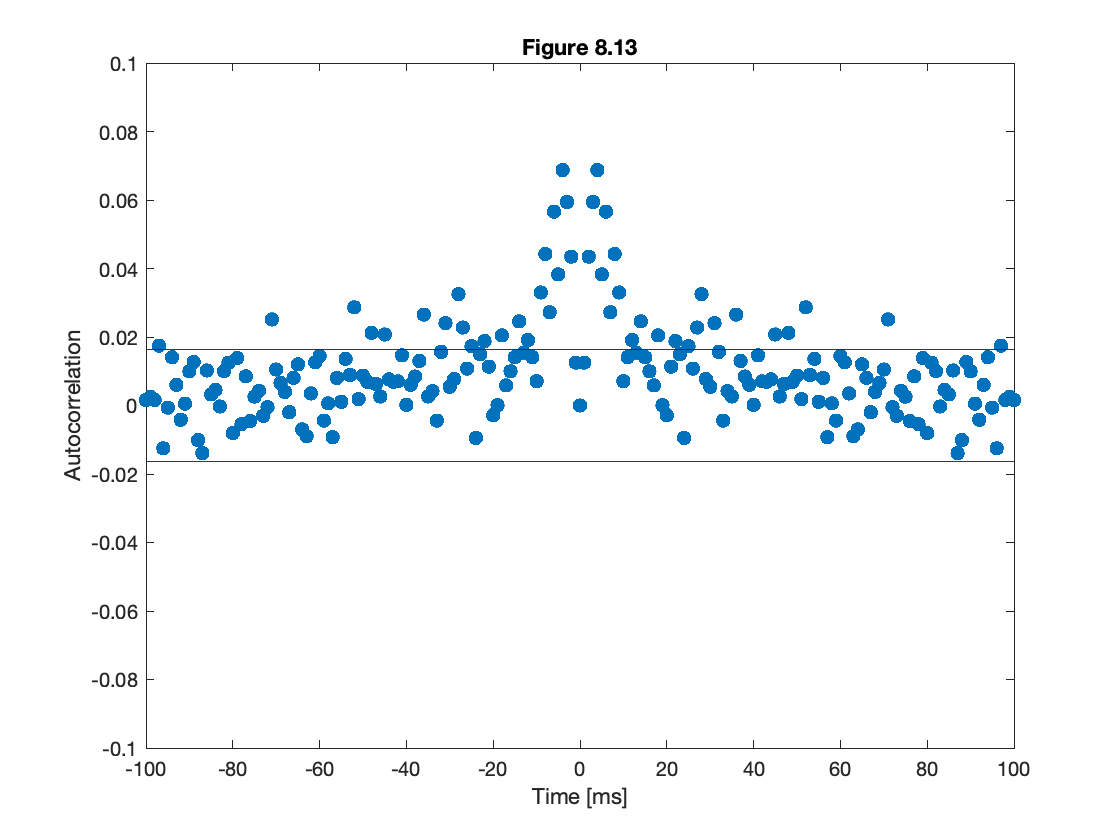

In [16]:
ACFDiff = ACFHigh - ACFLow; %Compute difference of autocorrelations,

% ... and plot it with upper and lower significance lines,
figure
plot(-100:100, ACFDiff, '.', 'MarkerSize', 20)
yline([2 * sqrt(1 / N1 + 1 / N2) 2 * sqrt(1 / N1 + 1 / N2)])
yline(- [2 * sqrt(1 / N1 + 1 / N2) 2 * sqrt(1 / N1 + 1 / N2)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.13')


## Step 5

### Figure 8.14

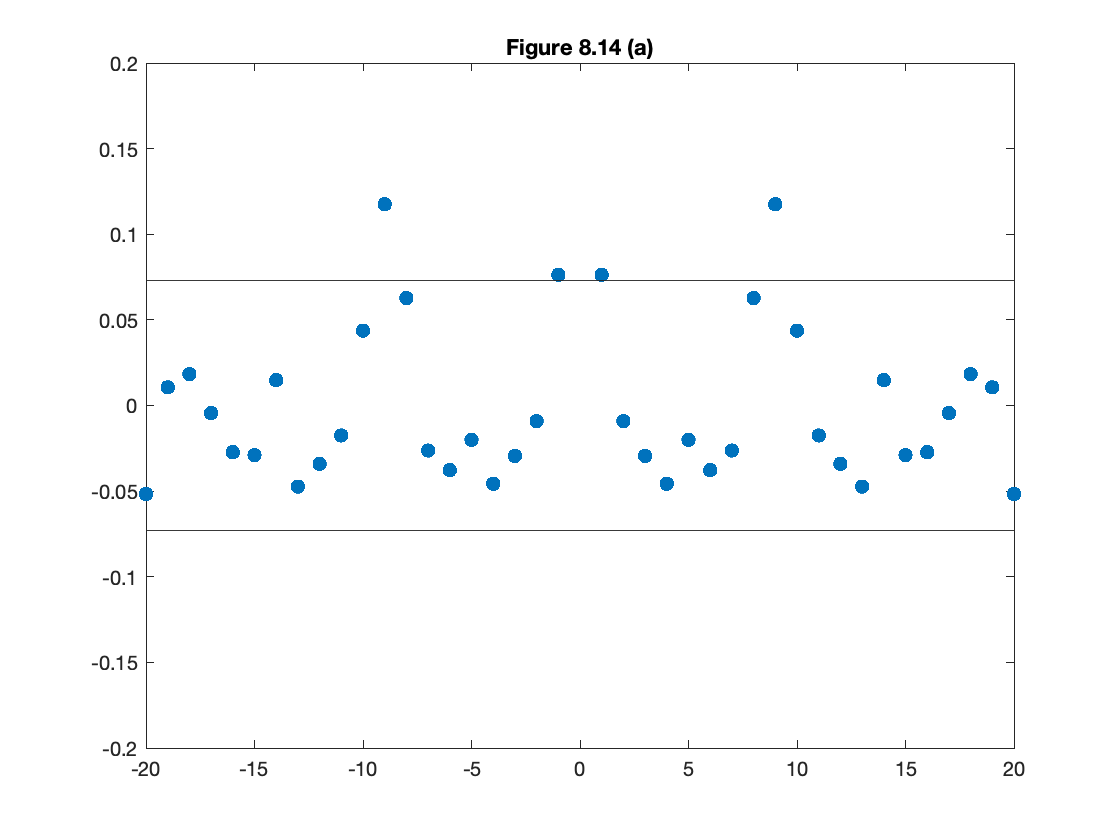

In [17]:
% Compute and plot the autocorrelation of the low light ISIs,
ISI_ACF_Low = xcorr(ISIsLow - mean(ISIsLow), 20, 'coeff');
N3 = length(ISIsLow);

figure
plot(-20:20, ISI_ACF_Low, '.','MarkerSize', 20) % Plot autocorrelation vs lags,
%  with upper and lower significance lines,
yline([2 / sqrt(N3) 2 / sqrt(N3)])
yline(- [2 / sqrt(N3) 2 / sqrt(N3)])
xlim([-20, 20]) %... set x-limits,
ylim([-0.2, 0.2]) %... and y-limits.
title('Figure 8.14 (a)')

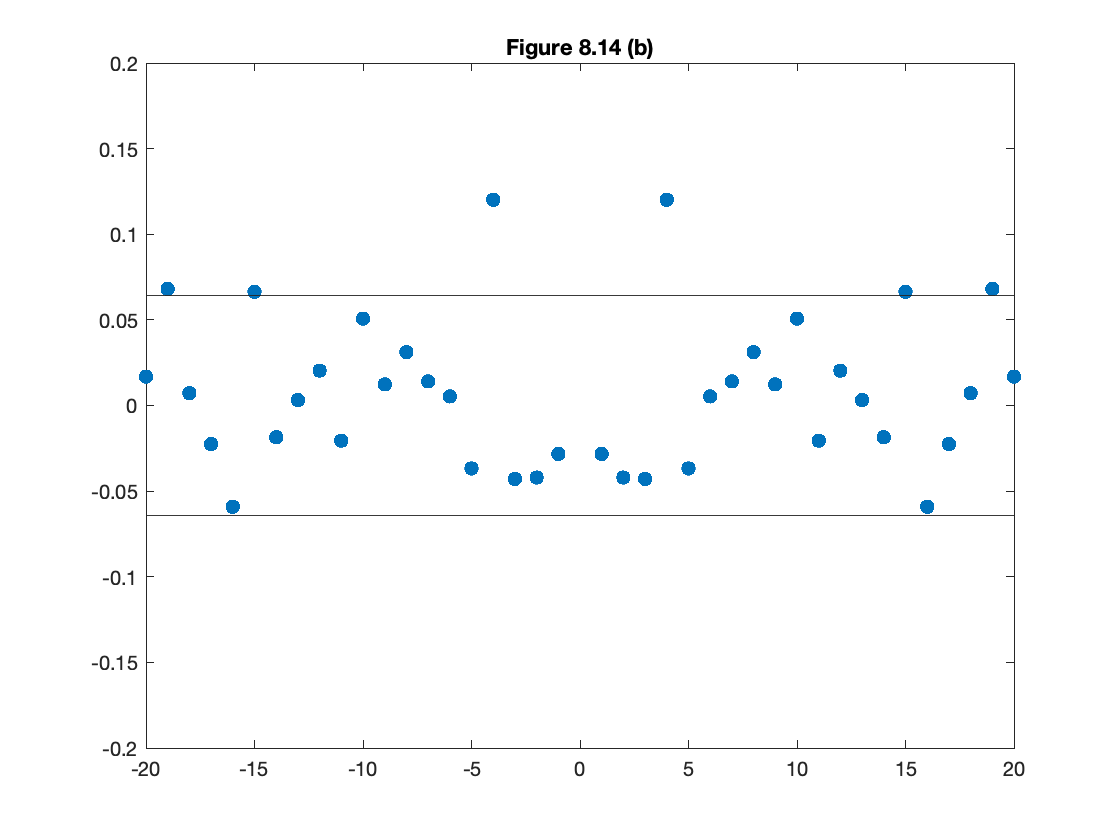

In [18]:
% Compute and plot the autocorrelation of the high light ISIs,
ISI_ACF_High = xcorr(ISIsHigh - mean(ISIsHigh), 20, 'coeff');
N4 = length(ISIsHigh);

figure
plot(-20:20, ISI_ACF_High, '.','MarkerSize', 20) % Plot autocorrelation vs lags,
%  with upper and lower significance lines,
yline([2 / sqrt(N4) 2 / sqrt(N4)])
yline(- [2 / sqrt(N4) 2 / sqrt(N4)])
xlim([-20, 20]) %... set x-limits,
ylim([-0.2, 0.2]) %... and y-limits.
title('Figure 8.14 (b)')

## Step 6

### Figure 8.15

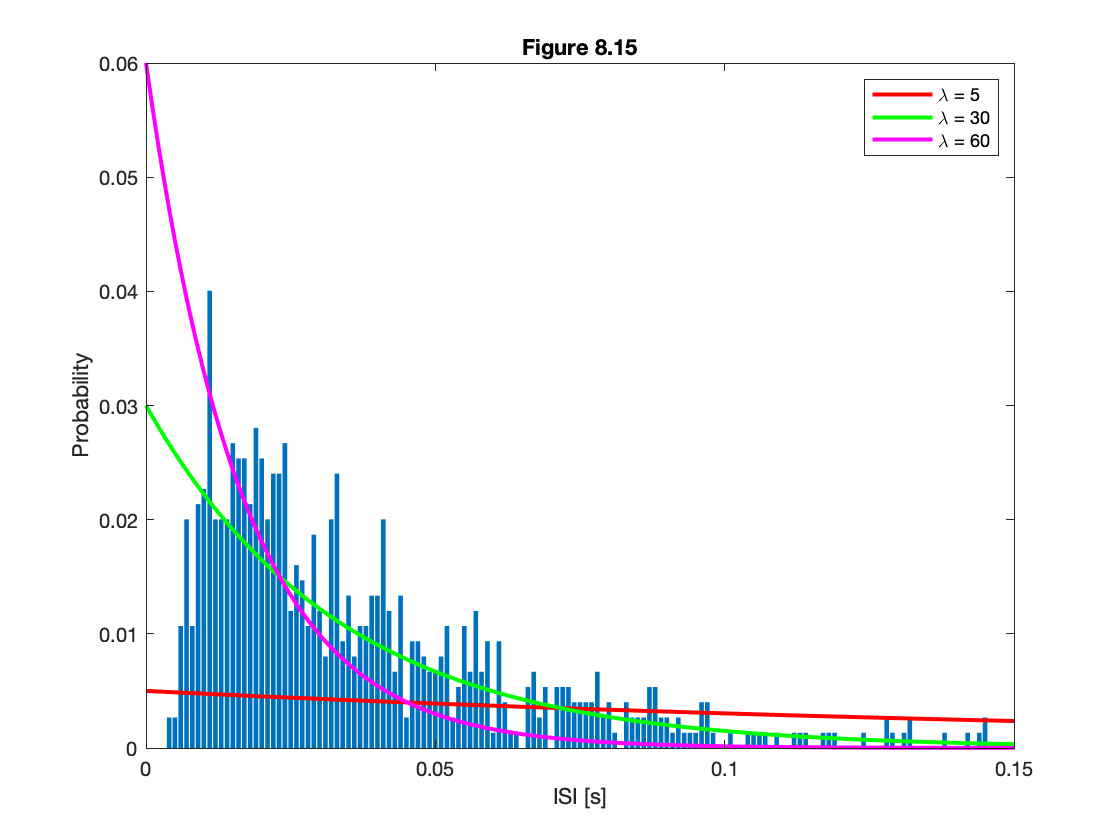

In [28]:
bins = (0:0.001:0.5); %Define 1 ms bins for histogram,
counts = hist(ISIsLow, bins); % compute histogram of ISIs,
prob = counts / length(ISIsLow); % convert to probability,

figure
bar(bins, prob); % and plot it,
hold on % freeze the graphics window,

lambda = 5; %Choose a value for lambda,
model = lambda * exp(-lambda * bins) * 0.001; % and create model,
h1 = plot(bins, model, 'r', 'LineWidth', 2); % plot the model in red,

lambda = 30;
model = lambda * exp(-lambda * bins) * 0.001; % and create model,
h2 = plot(bins, model, 'g', 'LineWidth', 2); % plot the model in green,

lambda = 60;
model = lambda * exp(-lambda * bins) * 0.001; % and create model,
h3 = plot(bins, model, 'm', 'LineWidth', 2); % plot the model in blue,

legend([h1 h2 h3], {'\lambda = 5', '\lambda = 30', '\lambda = 60'}) % add a legend,
xlim([0 0.15]) % with fixed x-limits,
ylim([0 .06]) % and fixed y-limits,
xlabel('ISI [s]') % and with x-axis labeled,
ylabel('Probability') % and y-axis labeled.
title('Figure 8.15')


### Figure 8.16

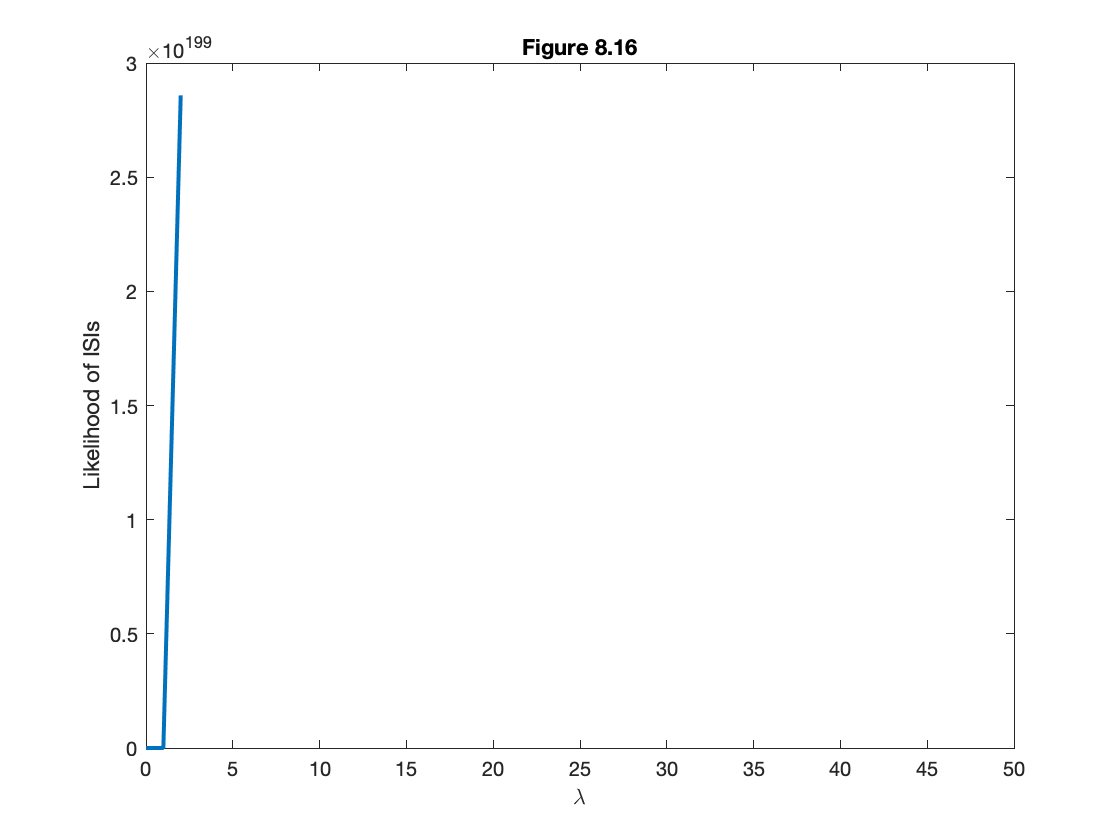

In [34]:
lambdas = 0:1:50; %Range of lambda values.
N3 = length(ISIsLow); %Number of low light ISIs observed.
L = lambdas .^ N3 .* exp(-lambdas * sum(ISIsLow)); %Compute likelihood,

figure
plot(lambdas, L, 'LineWidth', 2) %...and plot it.
xlim([0 50]) %...set x-limits,
xlabel('\lambda') %...and label the x-axis.
ylabel('Likelihood of ISIs') %...and label the y-axis.
title('Figure 8.16')


### Figure 8.17

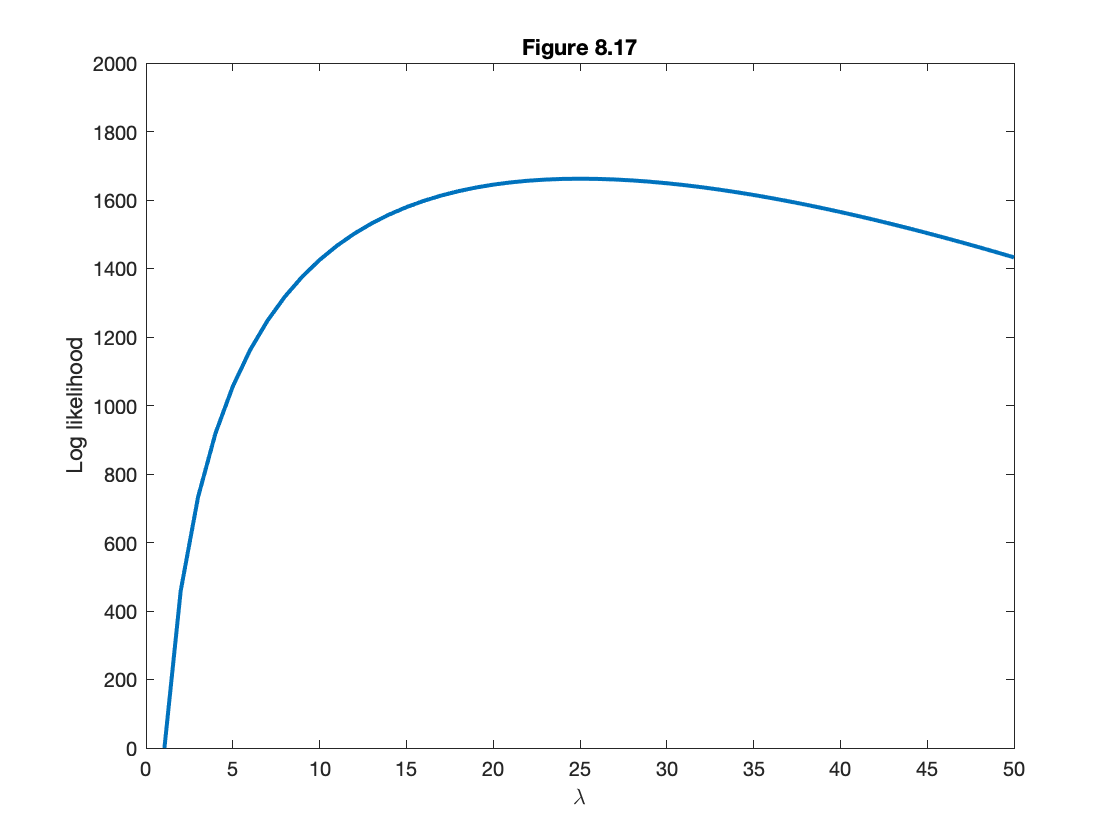

In [35]:
lambdas = 0:1:50; %Range of lambda values.
N3 = length(ISIsLow); %Number of low light ISIs observed.
l = N3 * log(lambdas) - lambdas * sum(ISIsLow); %Compute log likelihood,

figure
plot(lambdas, l, 'LineWidth', 2) %...and plot it.
xlim([0 50]) %...set x-limits,
ylim([0 2000])
xlabel('\lambda') %...and label the x-axis.
ylabel('Log likelihood') %...and label the y-axis.
title('Figure 8.17')


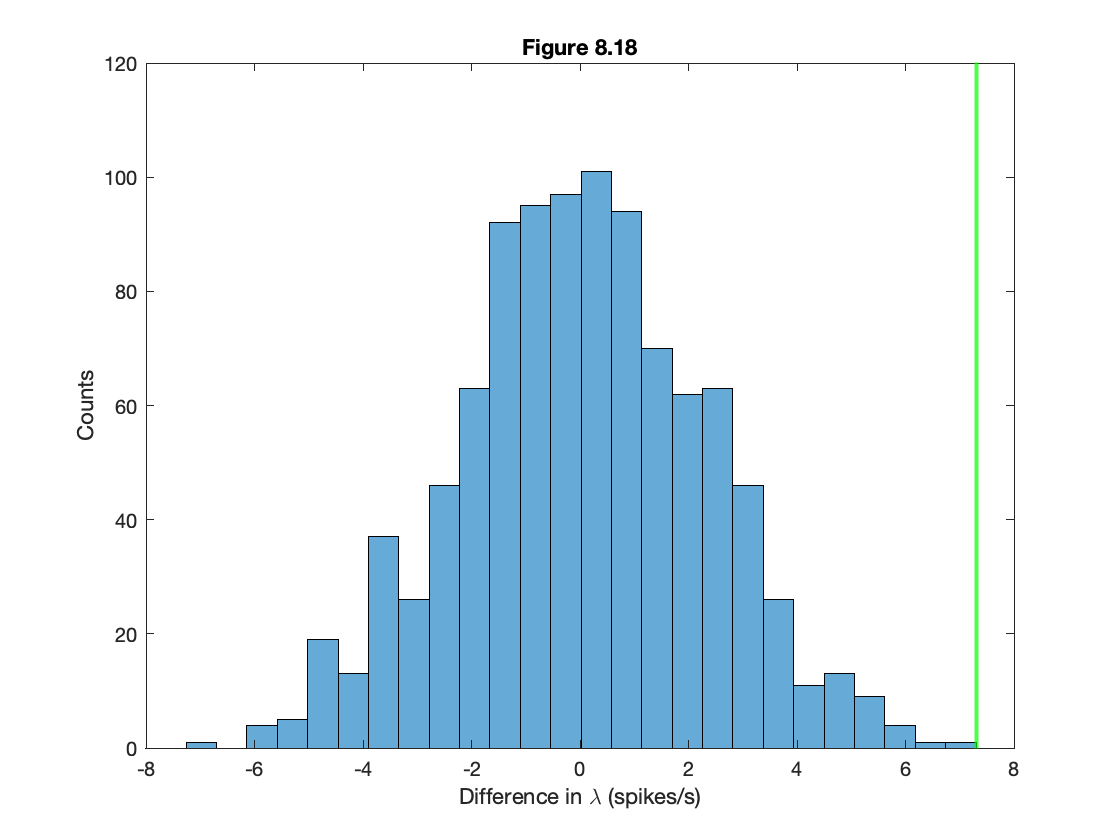

In [39]:
% Compute observed difference in lambdas,
MLDiff = 1 / mean(ISIsHigh) - 1 / mean(ISIsLow);

% And then perform the bootstrap analysis.
ISIs = [ISIsLow ISIsHigh]; %Merge all ISIs.
Nall = length(ISIs); %Save length of all ISIs.
Nlo = length(ISIsLow); %Save length of low light condition.
Nhi = length(ISIsHigh); %Save length of high light condition.

SampDiff = zeros(1, 1000); %Initialize the vector for bootstrap samples.

for i = 1:1000 %For each bootstrap sample,
    sampLo = ISIs(randsample(Nall, Nlo, 1)); %...resample low light ISIs,
    sampHi = ISIs(randsample(Nall, Nhi, 1)); %...resample low light ISIs,
    SampDiff(i) = 1 / mean(sampHi) - 1 / mean(sampLo); %...and difference.
end

figure
histogram(SampDiff, 30) %Plot resampled ISIs distribution,
xline(MLDiff, 'g', 'LineWidth', 2); %... and the empirical ISIs.
xlim([-1, 1] * 8)
xlabel('Difference in \lambda (spikes/s)') %... label the x-axis,
ylabel('Counts') %... and the y-axis.
title('Figure 8.18')


### Figure 8.19

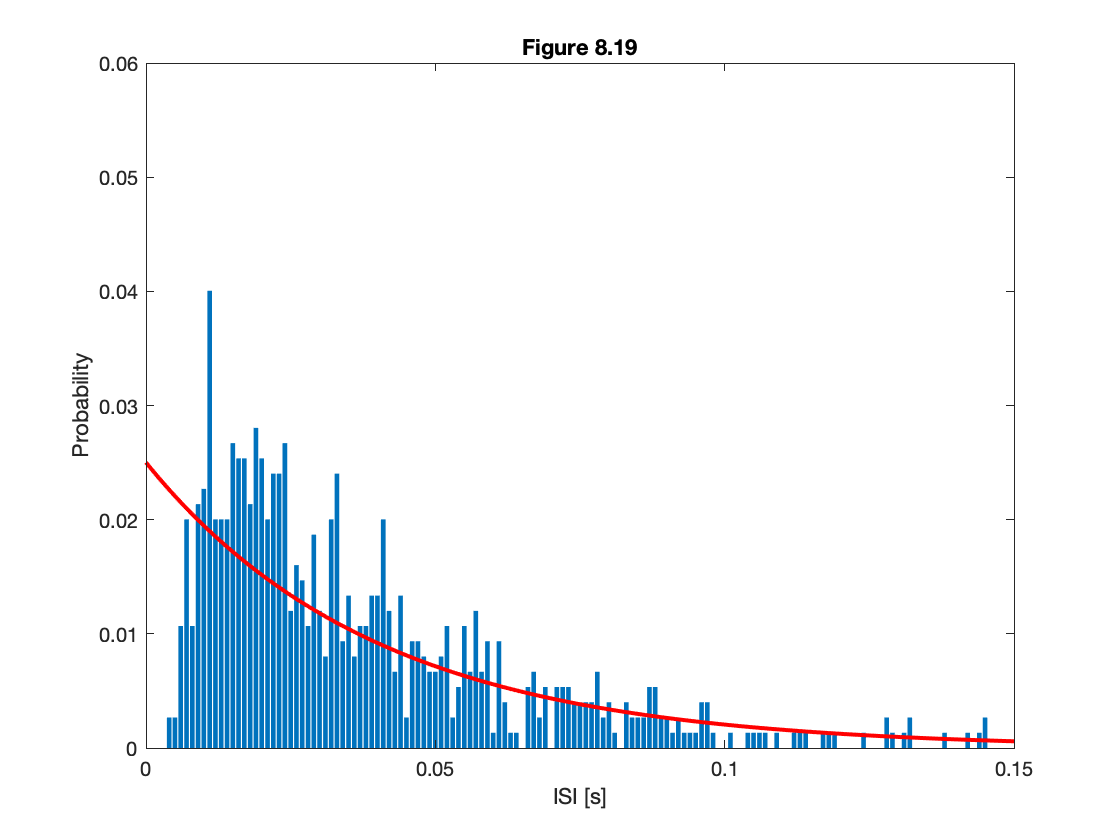

In [43]:
bins = (0:0.001:0.5); %Define 1 ms bins for histogram.
counts = hist(ISIsLow, bins); %Compute histogram,
prob = counts / length(ISIsLow); %... convert to probability,

figure
bar(bins, prob); %... and plot probability.
lambda = 1 / mean(ISIsLow); %Compute best guess for lambda,
model = lambda * exp(-lambda * bins) * .001; %... build the model,
hold on %... and plot it.
plot(bins, model, 'r','LineWidth', 2)
hold off
xlim([0 0.15]) %... xlim from 0 to 150 ms,
ylim([0 .06]) %... and ylim from 0 to 0.06,
xlabel('ISI [s]') %... label the x-axis,
ylabel('Probability') %... and label the y-axis.
title('Figure 8.19')


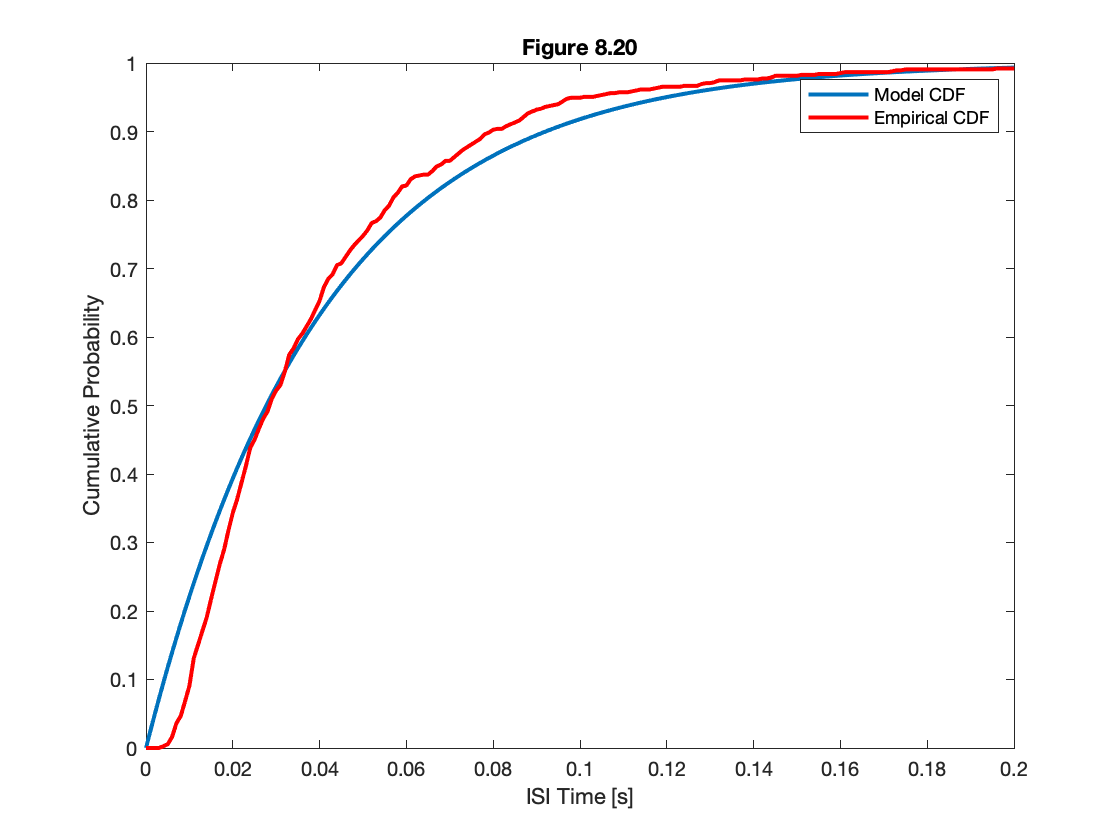

In [46]:
bins = (0:0.001:0.5); %Define 1 ms bins for histogram.
lambda = 1 / mean(ISIsLow); %Compute best guess for lambda,
FmodLow = 1 - exp(-lambda * bins); %... and define model CDF.
FempLow = cumsum(prob); %Define empirical CDF.

figure
h1 = plot(bins, FmodLow, 'LineWidth', 2); %Plot the model CDF,
hold on
h2 = plot(bins, FempLow, 'r', 'LineWidth', 2); %... and the empirical CDF,
legend([h1 h2], {'Model CDF', 'Empirical CDF'}) %... add a legend,
xlim([0 0.2]) %... with specified x-limits.
ylim([0 1])
xlabel('ISI Time [s]')
ylabel('Cumulative Probability')
title('Figure 8.20')


### Figure 8.21

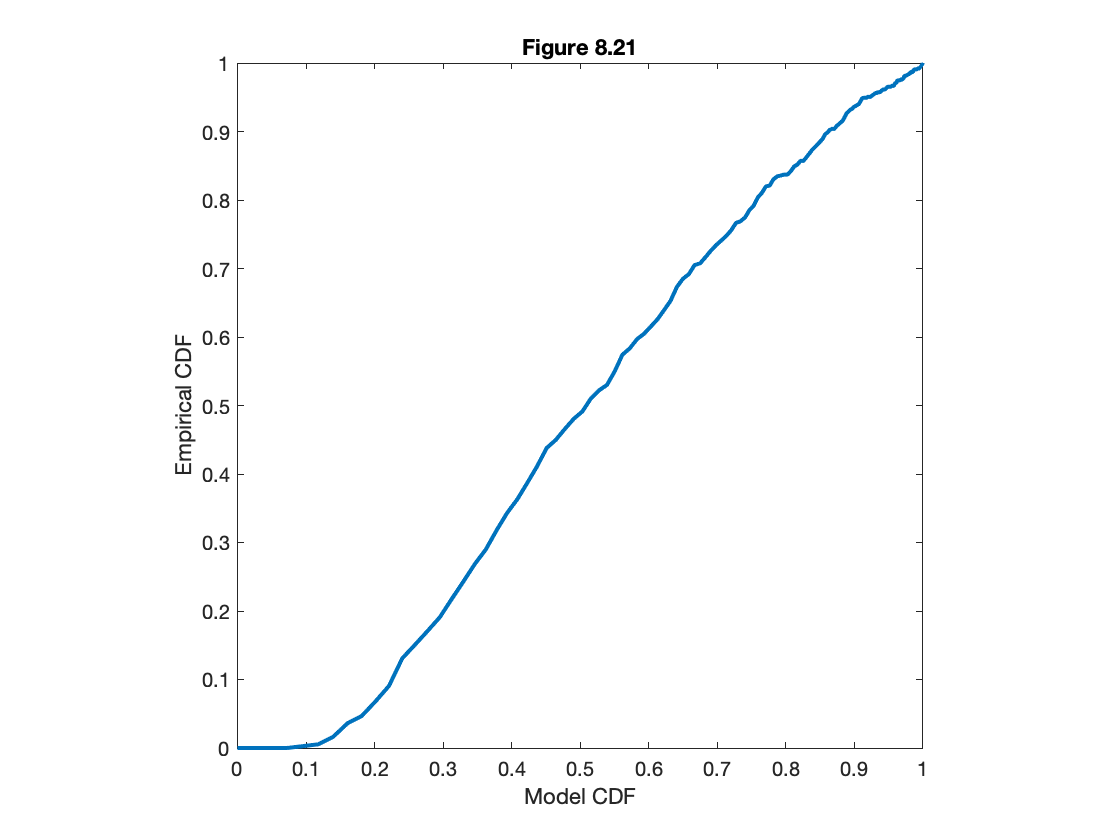

In [50]:
figure
plot(FmodLow, FempLow, 'LineWidth', 2) % plot model vs empirical CDFs.
axis([0 1 0 1]) % set the axes ranges.
axis square
xlabel('Model CDF') % label the x-axis.
ylabel('Empirical CDF') % label the y-axis.
title('Figure 8.21')


### Figure 8.22

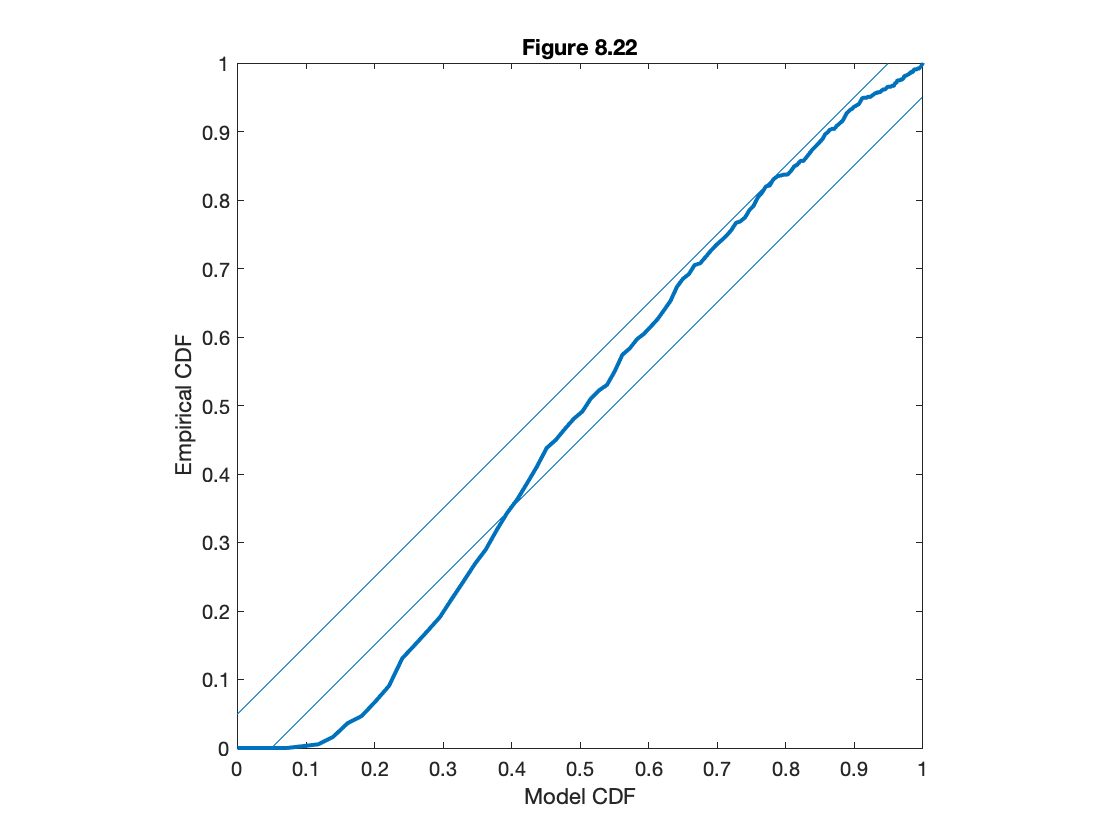

In [52]:
Nlow = length(ISIsLow); %Length of low light condition.

figure
plot(FmodLow, FempLow, "LineWidth", 2) %Plot model vs empirical CDFs.
%Plot the upper and lower confidence bounds,
line([0 1], [0 1] + 1.36 / sqrt(Nlow));
line([0 1], [0 1] - 1.36 / sqrt(Nlow));
axis([0 1 0 1]) %... with fixed axes.
axis square
xlabel('Model CDF') % label the x-axis.
ylabel('Empirical CDF') % label the y-axis.
title('Figure 8.22')


### A more advanced statistical model

In [64]:
bins = (0:0.001:0.5); %Define 1 ms bins.
Nlow = length(ISIsLow); %Length low light condition.
mu = mean(ISIsLow); %Mean of inverse Gaussian.
lambda = 1 / mean(1 ./ ISIsLow - 1 / mu); %... and shape parameter,
model = sqrt(lambda / 2 / pi ./ bins .^ 3) .* ... %... to create model.
    exp(-lambda .* (bins - mu) .^ 2/2 / mu ^ 2 ./ bins) * .001;
model(1) = 0;

edges = [bins, bins(end) + 0.001]; % define edges of bins for histogram.
counts = histcounts(ISIsLow, edges); %Compute histogram,
prob = counts / length(ISIsLow); %... convert to probability,
FmodLow = cumsum(model); %Define the model CDF,
FempLow = cumsum(prob); %...and define empirical CDF,


### Figure 8.23

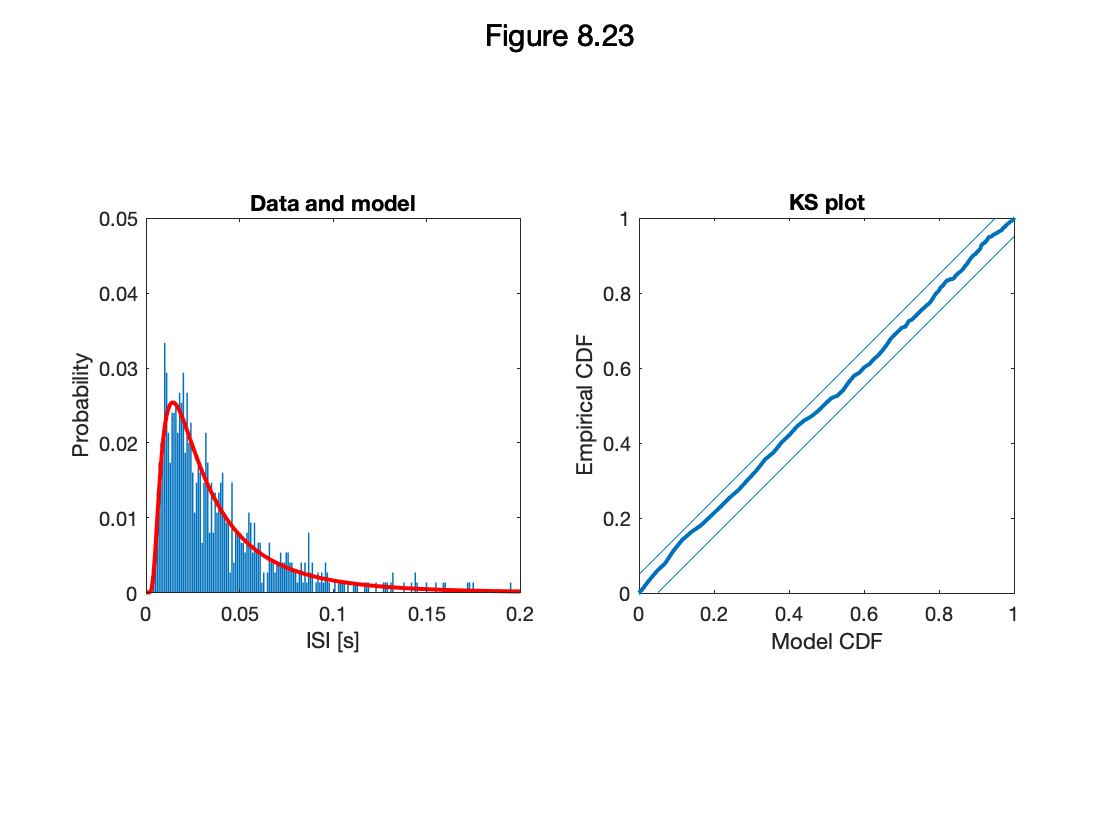

In [69]:
% Plot the data and the model,
figure
subplot(1, 2, 1)
bar(bins, prob); %... and plot probability.
hold on
plot(bins, model, 'r', 'LineWidth', 2); %Plot the model.
xlim([0 0.2]) %xlim from 0 to 200 ms.
ylim([0 .05]) %ylim from 0 to 0.05,
axis square
xlabel('ISI [s]') %Label the x-axis,
ylabel('Probability') %... and the y-axis.
title('Data and model')

% Plot the KS plot.
subplot(1, 2, 2)
plot(FmodLow, FempLow, "LineWidth", 2) %...plot model vs empirical CDF,
line([0 1], [0 1] + 1.36 / sqrt(Nlow)); %...upper confidence bound,
line([0 1], [0 1] - 1.36 / sqrt(Nlow)); %...lower confidence bound,
axis([0 1 0 1]) %... set the axes ranges,
axis square
xlabel('Model CDF') %... and label the axes.
ylabel('Empirical CDF')
title('KS plot')

sgtitle('Figure 8.23') %... and add a title to the figure.
